In [1]:
# %%
# ============================================================
# Drought Indices Computation — CPC 0.25° (1979–2021)
# PDSI | scPDSI | TMDSI — First 20 Grids
# ============================================================

import sys
sys.path.insert(0, r"C:\Users\ktripat\Dropbox\Python_Packages\tmdsi")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import time
from tmdsi.indices.drought_indices import compute_pdsi, compute_scpdsi, compute_tmdsi

In [2]:

# ============================================================
# 1. LOAD DATA
# ============================================================

print("Loading data...")

latlon = pd.read_csv(
    r"E:\Datasets\CPC\Monthly\latlon.txt",
    sep='\t', header=None
).values                             # (78016, 2): col0=lon, col1=lat
lons = latlon[:, 0]
lats = latlon[:, 1]

tmax_df   = pd.read_csv(r"E:\Datasets\CPC\Monthly\mon_tmax_1979_2021_world.txt",        sep='\t', header=None)
tmin_df   = pd.read_csv(r"E:\Datasets\CPC\Monthly\mon_tmin_1979_2021_world.txt",        sep='\t', header=None)
precip_df = pd.read_csv(r"E:\Datasets\CPC\Monthly\mon_totalPrecip_1979_2021_world.txt", sep='\t', header=None)

# col 0 = year, col 1 = month, col 2: = grid data
tmax_data   = tmax_df.iloc[:, 2:].values.astype(float)     # (516, 78016)
tmin_data   = tmin_df.iloc[:, 2:].values.astype(float)
precip_data = precip_df.iloc[:, 2:].values.astype(float)

# mask bad/missing values
tmax_data  [tmax_data   < -100] = np.nan
tmin_data  [tmin_data   < -100] = np.nan
precip_data[precip_data < 0   ] = np.nan

N_MONTHS = tmax_data.shape[0]    # 516
N_GRIDS  = tmax_data.shape[1]    # 78016
print(f"  Loaded: {N_MONTHS} months × {N_GRIDS} grids")
print(f"  Tmax range : {np.nanmin(tmax_data):.1f} to {np.nanmax(tmax_data):.1f} °C")
print(f"  Precip range: {np.nanmin(precip_data):.1f} to {np.nanmax(precip_data):.1f} mm")



Loading data...
  Loaded: 516 months × 78016 grids
  Tmax range : -54.0 to 49.8 °C
  Precip range: 0.0 to 9578.2 mm


In [3]:
# %%
# ============================================================
# 2. AWC — Load from R (cszang/awc package, Webb et al. 2000)
# ============================================================

awc_df  = pd.read_csv(r"E:\Datasets\CPC\Monthly\awc_cpc.txt", sep="\t")
awc_all = awc_df["awc_mm"].values.astype(float)

# replace NA/NaN with 150mm (Palmer default) so indices don't break
awc_all = np.where(np.isnan(awc_all), 150.0, awc_all)
# also replace zeros — no soil has truly zero AWC
awc_all = np.where(awc_all <= 0, 150.0, awc_all)
# cap AWC at 300mm — physically justified maximum rooting zone
# awc_all = np.clip(awc_all, 10.0, 300.0)
print(f"AWC loaded: {len(awc_all)} grids")
print(f"AWC range : {awc_all.min():.0f} to {awc_all.max():.0f} mm")
print(f"AWC mean  : {awc_all.mean():.0f} mm")
print(f"Filled NA/zero with 150mm: {(awc_df['awc_mm'].isna() | (awc_df['awc_mm'] <= 0)).sum()} grids")

AWC loaded: 78016 grids
AWC range : 1 to 2160 mm
AWC mean  : 247 mm
Filled NA/zero with 150mm: 21 grids


In [22]:
# %%
# ============================================================
# 3. COMPUTE ALL THREE INDICES — ALL GRIDS
# ============================================================

from tmdsi.indices.drought_indices import compute_pdsi, compute_scpdsi, compute_tmdsi
from joblib import Parallel, delayed

N_RUN = N_GRIDS   # 78016

# year/month columns
dates_df = pd.date_range("1979-01", periods=N_MONTHS, freq="MS")
year_col  = dates_df.year.values.reshape(-1, 1)   # (516, 1)
month_col = dates_df.month.values.reshape(-1, 1)  # (516, 1)

# pre-allocate
pdsi_out   = np.full((N_MONTHS, N_RUN), np.nan, dtype=np.float32)
scpdsi_out = np.full((N_MONTHS, N_RUN), np.nan, dtype=np.float32)
tmdsi_out  = np.full((N_MONTHS, N_RUN), np.nan, dtype=np.float32)
sc_p       = np.full(N_RUN, np.nan)
sc_q       = np.full(N_RUN, np.nan)
tm_phi     = np.full((12, N_RUN), np.nan)
tm_w       = np.full((12, N_RUN), np.nan)

def compute_one(g):
    p  = precip_data[:, g]
    tx = tmax_data  [:, g]
    tn = tmin_data  [:, g]
    if np.all(np.isnan(p)) or np.all(np.isnan(tx)):
        return g, None
    kw = dict(
        awc                    = awc_all[g],
        latitude               = lats[g],
        data_start_year        = 1979,
        calibration_start_year = 1979,
        calibration_end_year   = 2010,
        pet_method             = "thornthwaite",
    )
    try:
        r1 = compute_pdsi  (p, tx, tn, **kw)
        r2 = compute_scpdsi(p, tx, tn, **kw)
        r3 = compute_tmdsi (p, tx, tn, **kw)
        return g, (r1.index, r2.index, r3.index, r2.p, r2.q, r3.phi, r3.w)
    except Exception as e:
        return g, None

print(f"Computing all {N_RUN} grids in parallel...")
t0 = time.time()

results = Parallel(n_jobs=-1, verbose=5)(
    delayed(compute_one)(g) for g in range(N_RUN)
)

for g, res in results:
    if res is None:
        continue
    pdsi_out  [:, g] = res[0]
    scpdsi_out[:, g] = res[1]
    tmdsi_out [:, g] = res[2]
    sc_p[g]          = res[3]
    sc_q[g]          = res[4]
    tm_phi[:, g]     = res[5]
    tm_w  [:, g]     = res[6]

print(f"Done in {(time.time()-t0)/60:.1f} min")

# %%
# ============================================================
# 4. SAVE — year | month | grid_0 ... grid_N
# ============================================================

SAVE_DIR = r"E:\Datasets\CPC\Monthly\DroughtIndices"
import os; os.makedirs(SAVE_DIR, exist_ok=True)

def save_index(arr, name):
    out = np.hstack([year_col, month_col, arr.astype(np.float32)])
    path = os.path.join(SAVE_DIR, f"{name}_cpc_1979_2021.txt")
    np.savetxt(path, out, fmt="%.4f", delimiter="\t")
    print(f"Saved {name} → {path}")

save_index(pdsi_out,   "pdsi")
save_index(scpdsi_out, "scpdsi")
save_index(tmdsi_out,  "tmdsi")

# save parameters too — useful for paper figures
np.savetxt(os.path.join(SAVE_DIR, "scpdsi_p_q.txt"),
           np.column_stack([lons, lats, sc_p, sc_q]),
           fmt="%.4f", delimiter="\t", header="lon\tlat\tp\tq")

np.savetxt(os.path.join(SAVE_DIR, "tmdsi_phi_w.txt"),
           np.column_stack([lons, lats, tm_phi.T, tm_w.T]),
           fmt="%.4f", delimiter="\t")

print("\nAll saved.")
print(f"File format: col1=year, col2=month, col3..N = 78016 grids")

Computing all 78016 grids in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done 240 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done 402 tasks      | elapsed:   15.6s
[Parallel(n_jobs=-1)]: Done 600 tasks      | elapsed:   22.0s
[Parallel(n_jobs=-1)]: Done 834 tasks      | elapsed:   29.4s
[Parallel(n_jobs=-1)]: Done 1104 tasks      | elapsed:   38.4s
[Parallel(n_jobs=-1)]: Done 1410 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 1752 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 2130 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 2544 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 2994 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 3480 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 4002 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 4560 tasks      | e

Done in 43.6 min
Saved pdsi → E:\Datasets\CPC\Monthly\DroughtIndices\pdsi_cpc_1979_2021.txt
Saved scpdsi → E:\Datasets\CPC\Monthly\DroughtIndices\scpdsi_cpc_1979_2021.txt
Saved tmdsi → E:\Datasets\CPC\Monthly\DroughtIndices\tmdsi_cpc_1979_2021.txt

All saved.
File format: col1=year, col2=month, col3..N = 78016 grids


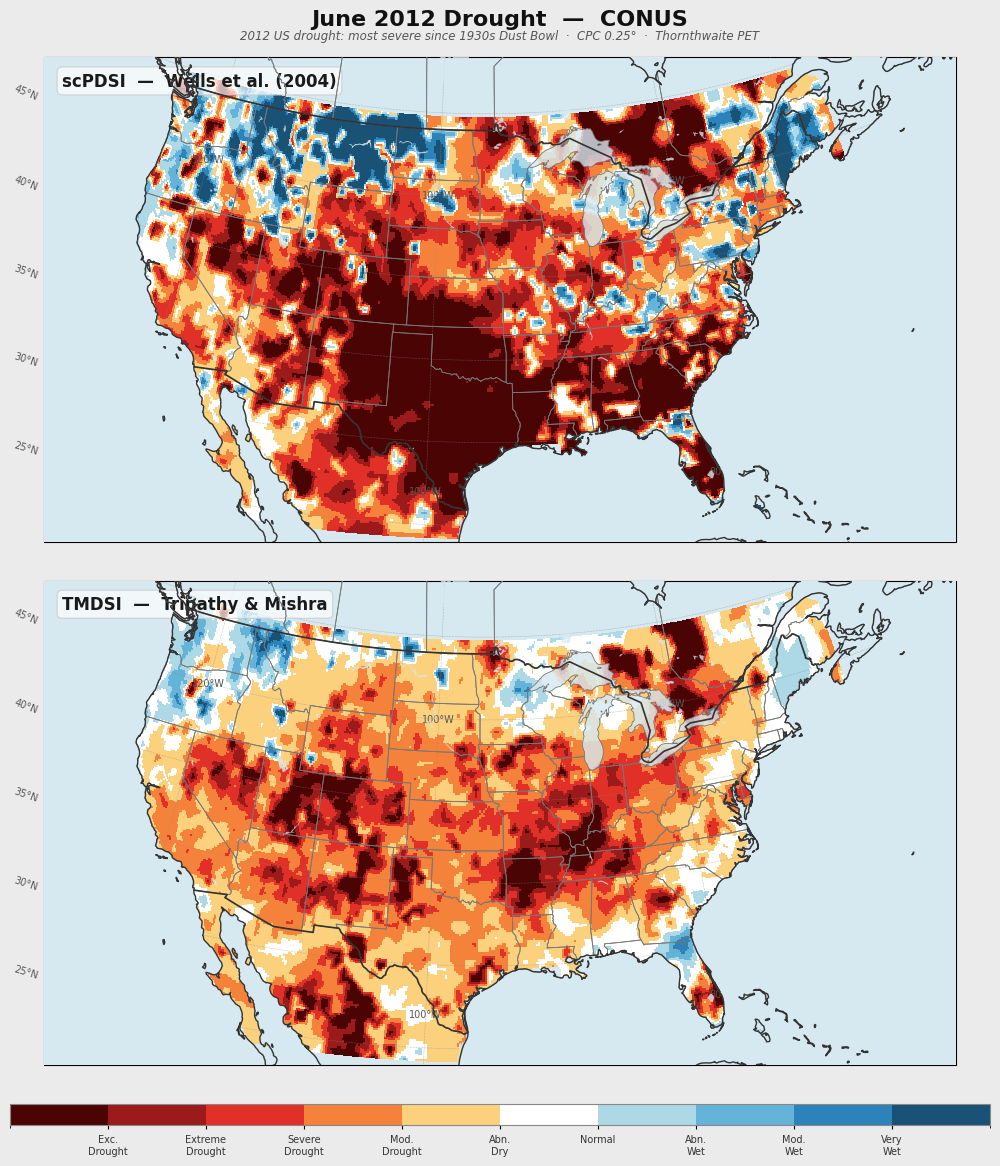

Saved: drought_map_dec2012.png


In [29]:
# %%
# ============================================================
# 5. MAP — June 2012 | scPDSI vs TMDSI | CONUS style
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata

# ── extract June 2012 ────────────────────────────────────────
row_idx = np.where((dates_df.year == 2012) & (dates_df.month == 6))[0][0]

# USA mask
usa_mask = ((lons >= -125) & (lons <= -65) &
            (lats >=   24) & (lats <=  50))

lons_us = lons[usa_mask]
lats_us = lats[usa_mask]
sc_us   = scpdsi_out[row_idx, usa_mask]
tm_us   = tmdsi_out [row_idx, usa_mask]

# ── interpolate to regular grid (like NOAA filled map) ────────
lon_grid = np.linspace(-125, -65,  400)
lat_grid = np.linspace(  24,  50,  200)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

points = np.column_stack([lons_us, lats_us])
sc_grid = griddata(points, sc_us, (LON, LAT), method='linear')
tm_grid = griddata(points, tm_us, (LON, LAT), method='linear')

# ── NOAA-style drought colormap ───────────────────────────────
# white=normal, yellow=abnormally dry, orange=moderate,
# red=severe, darkred=extreme, maroon=exceptional
# blue side for wet
# CORRECT: negative = drought (red), positive = wet (blue)
cmap_colors = [
    "#4A0404",   # exceptional drought  (< -4)
    "#9B1B1B",   # extreme drought      (-4 to -3)
    "#E03027",   # severe drought       (-3 to -2)
    "#F5823A",   # moderate drought     (-2 to -1)
    "#FCD17D",   # abnormally dry       (-1 to  0)
    "#FFFFFF",   # normal               ( 0 to  1)
    "#ADD8E6",   # abnormally wet       ( 1 to  2)
    "#64B3D9",   # moderately wet       ( 2 to  3)
    "#2B83BA",   # very wet             ( 3 to  4)
    "#1A5276",   # exceptionally wet    (> 4)
]
bounds = [-6, -4, -3, -2, -1, 0, 1, 2, 3, 4, 6]
cmap   = mcolors.ListedColormap(cmap_colors)
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

# ── plot ──────────────────────────────────────────────────────
proj = ccrs.LambertConformal(central_longitude=-96, central_latitude=37.5,
                              standard_parallels=(33, 45))

fig, axes = plt.subplots(
    2, 1, figsize=(14, 12),
    subplot_kw={"projection": proj},
    facecolor="#EBEBEB"
)
fig.patch.set_facecolor("#EBEBEB")

plot_data  = [sc_grid, tm_grid]
plot_titles = ["scPDSI  —  Wells et al. (2004)", "TMDSI  —  Tripathy & Mishra"]

for ax, grid, title in zip(axes, plot_data, plot_titles):

    # background
    ax.set_facecolor("#D6E8F0")

    # filled contour — the NOAA-style filled map
    cf = ax.pcolormesh(
        LON, LAT, grid,
        cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree(),
        zorder=2, shading='auto'
    )

    # features on top
    ax.add_feature(cfeature.OCEAN,    facecolor="#D6E8F0", zorder=3)
    ax.add_feature(cfeature.LAKES,    facecolor="#D6E8F0", zorder=3, alpha=0.8)
    ax.add_feature(cfeature.STATES,   edgecolor="#777777", linewidth=0.6,  zorder=4)
    ax.add_feature(cfeature.BORDERS,  edgecolor="#333333", linewidth=1.2,  zorder=5)
    ax.add_feature(cfeature.COASTLINE,edgecolor="#333333", linewidth=1.0,  zorder=5)

    ax.set_extent([-125, -65, 24, 50], crs=ccrs.PlateCarree())

    # title inside map top-left
    ax.text(0.02, 0.97, title,
            transform=ax.transAxes,
            fontsize=12, fontweight="bold",
            va="top", color="#1a1a1a",
            bbox=dict(facecolor="white", alpha=0.7,
                      edgecolor="#cccccc", boxstyle="round,pad=0.3"))

    # gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                      color="#888888", alpha=0.5, linestyle="--",
                      crs=ccrs.PlateCarree())
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 7, "color": "#555555"}
    gl.ylabel_style = {"size": 7, "color": "#555555"}

# ── shared horizontal colorbar ────────────────────────────────
cbar_ax = fig.add_axes([0.15, 0.04, 0.70, 0.018])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
                  ticks=[-4, -3, -2, -1, 0, 1, 2, 3, 4])
cb.ax.set_xticklabels(
    ["Exc.\nDrought", "Extreme\nDrought", "Severe\nDrought",
     "Mod.\nDrought", "Abn.\nDry",
     "Normal",
     "Abn.\nWet", "Mod.\nWet", "Very\nWet"],
    fontsize=7, color="#333333"
)
cb.outline.set_edgecolor("#888888")
cb.ax.tick_params(size=3)
# ── main title ────────────────────────────────────────────────
fig.suptitle(
    "June 2012 Drought  —  CONUS",
    fontsize=16, fontweight="bold", y=0.97, color="#111111"
)
fig.text(
    0.5, 0.945,
    "2012 US drought: most severe since 1930s Dust Bowl  ·  CPC 0.25°  ·  Thornthwaite PET",
    ha="center", fontsize=8.5, color="#555555", style="italic"
)

plt.subplots_adjust(top=0.93, bottom=0.09, left=0.02,
                    right=0.98, hspace=0.08)
plt.savefig("drought_map_dec2012.png", dpi=200,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: drought_map_dec2012.png")

Plotting europe_2003...


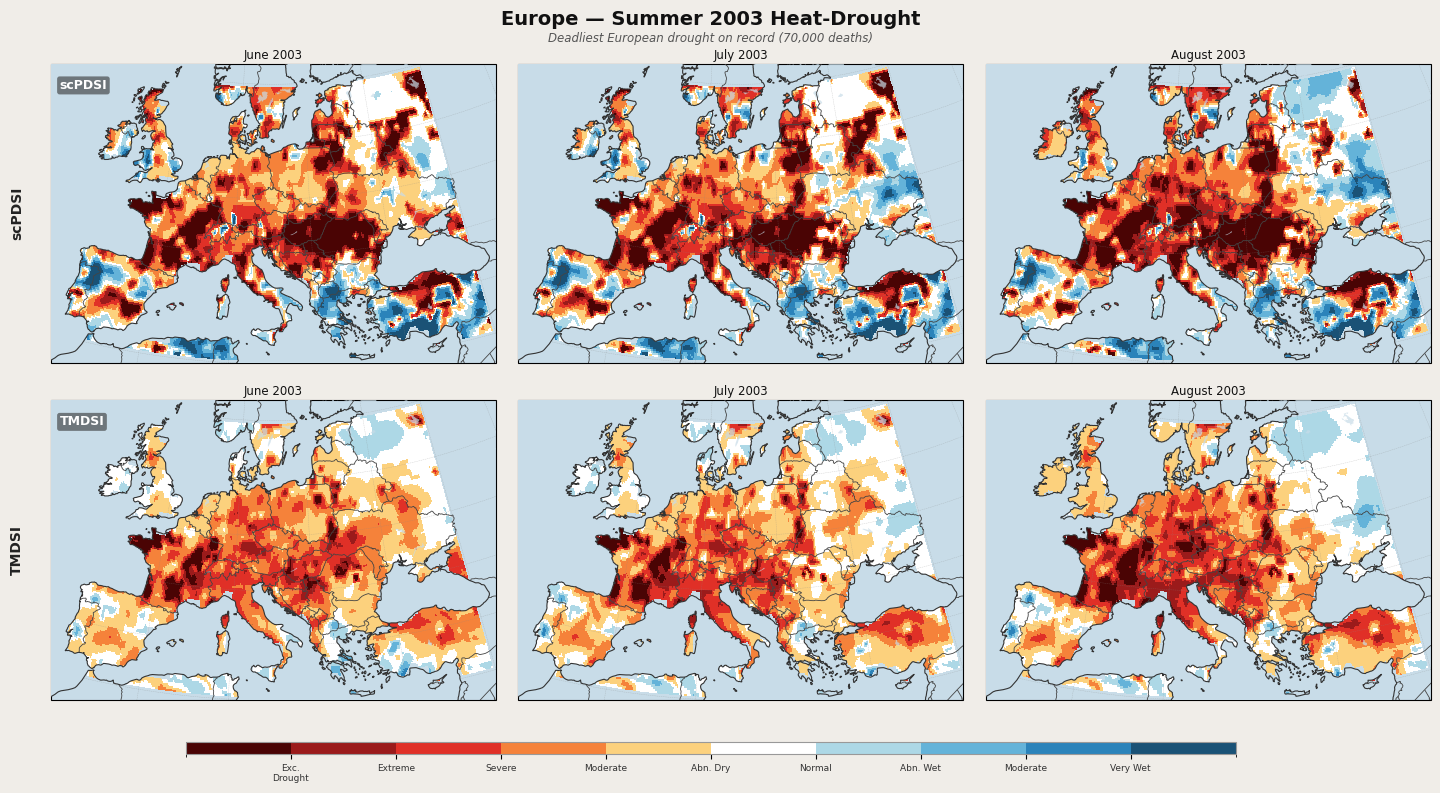

  Saved: drought_map_europe_2003.png
Plotting china_2010...


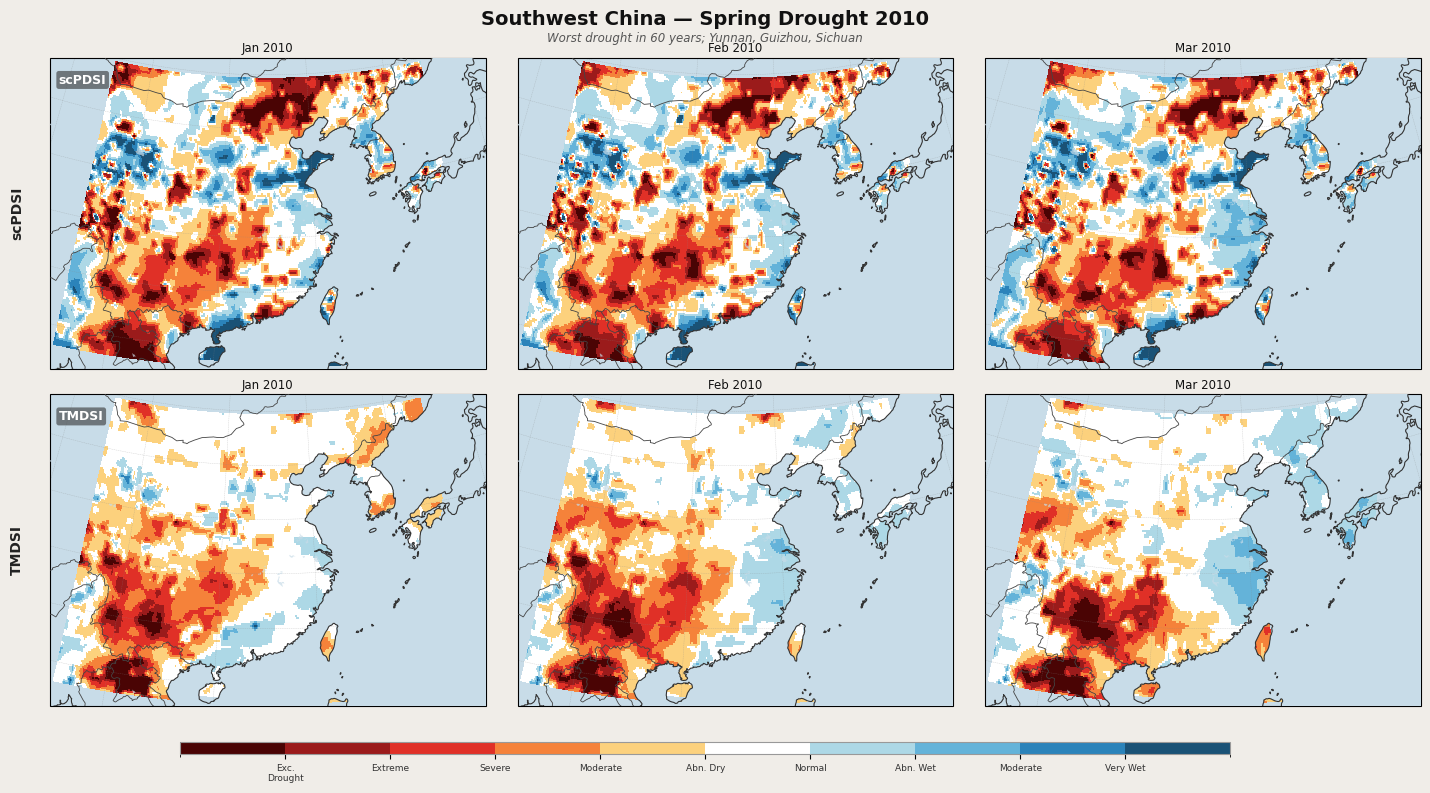

  Saved: drought_map_china_2010.png
Plotting australia_2002...


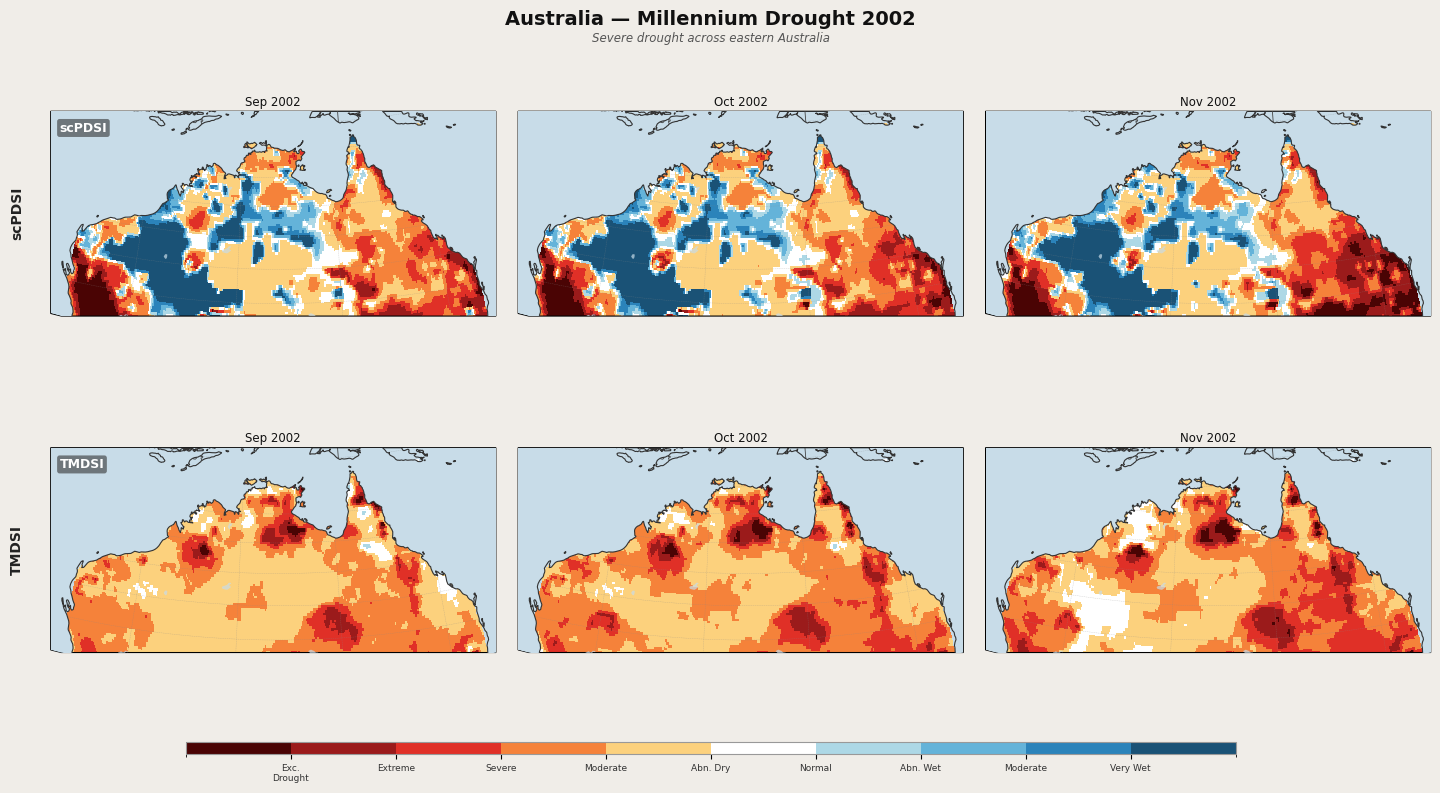

  Saved: drought_map_australia_2002.png
Plotting india_2009...


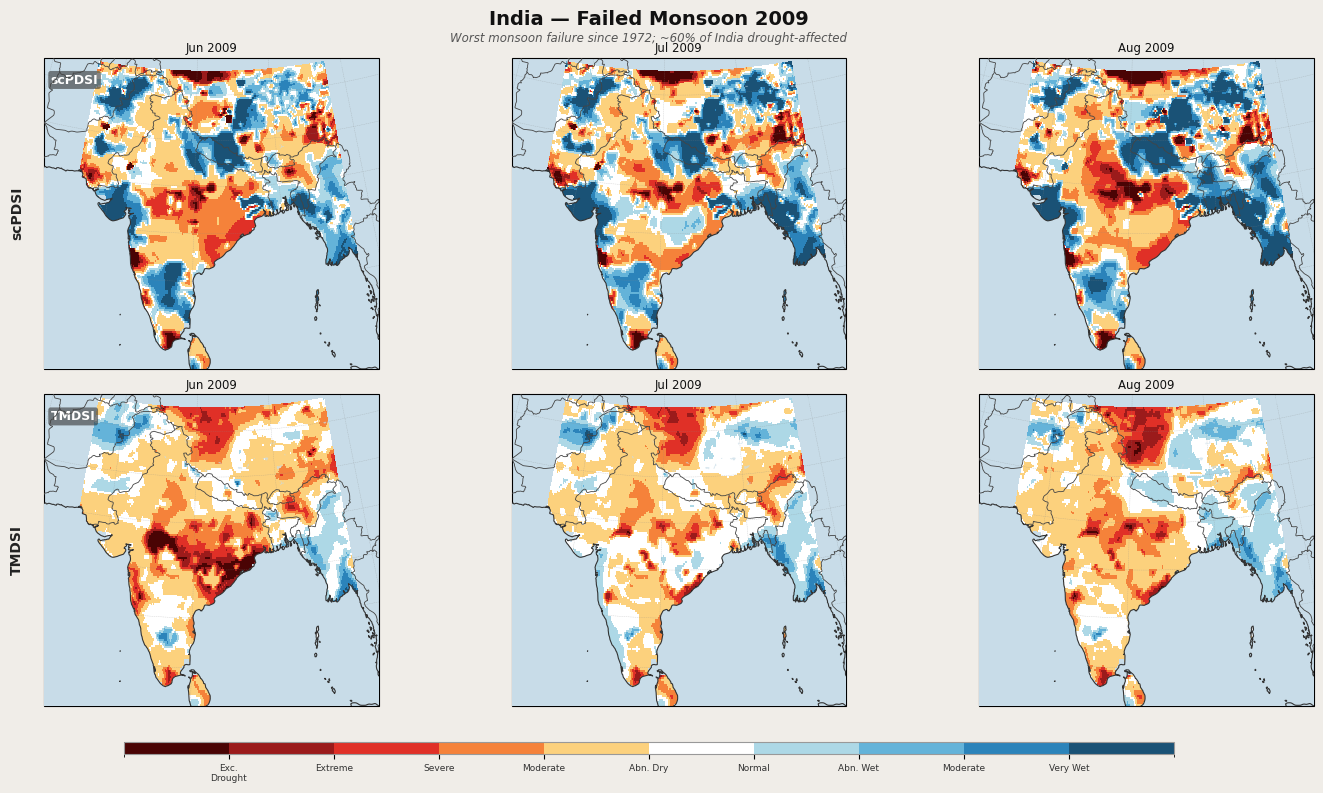

  Saved: drought_map_india_2009.png
Plotting africa_2011...


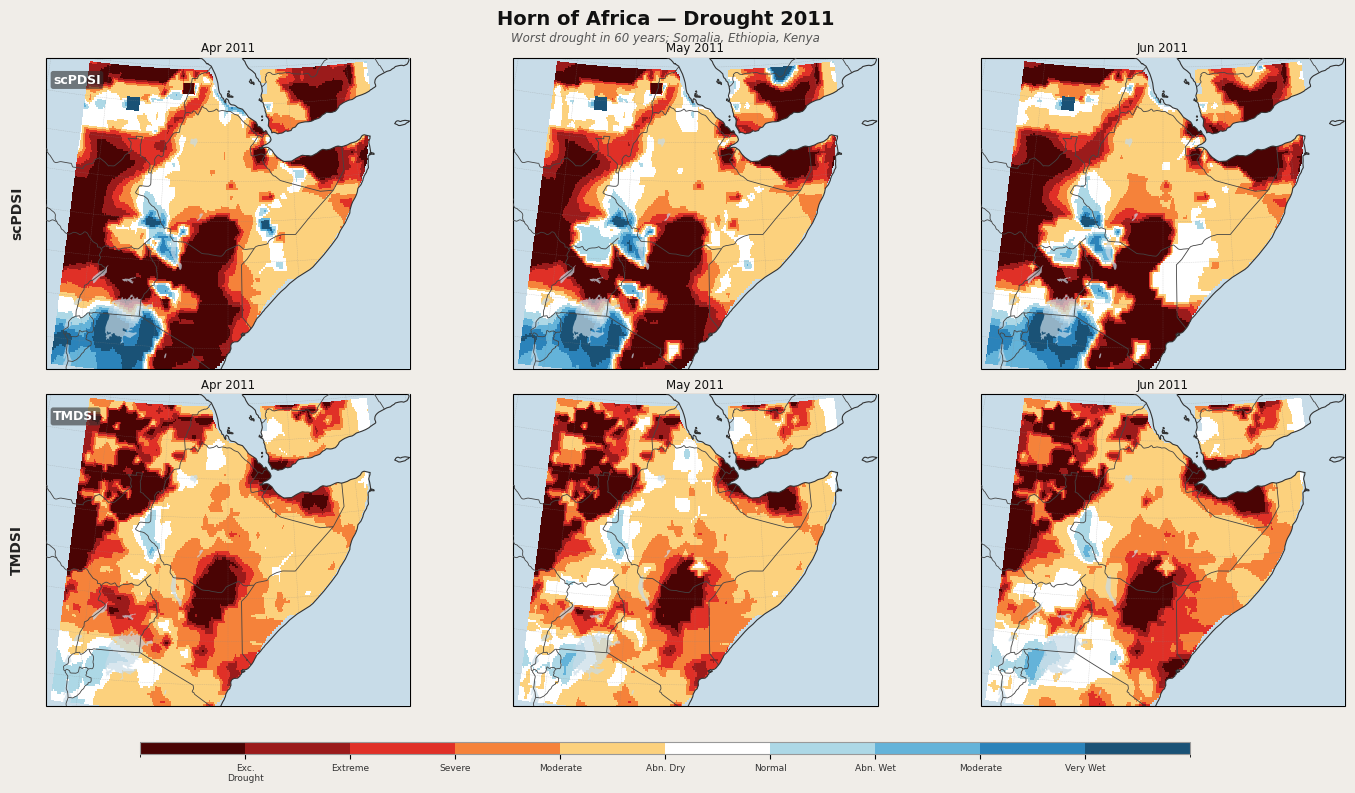

  Saved: drought_map_africa_2011.png

All maps done.


In [30]:
# %%
# ============================================================
# GLOBAL DROUGHT EVENTS — Spatial Maps
# scPDSI (row 1) vs TMDSI (row 2), 3 months each
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata

# ── drought colormap (negative=drought=red, positive=wet=blue) ──
cmap_colors = [
    "#4A0404", "#9B1B1B", "#E03027", "#F5823A", "#FCD17D",
    "#FFFFFF",
    "#ADD8E6", "#64B3D9", "#2B83BA", "#1A5276",
]
bounds = [-6, -4, -3, -2, -1, 0, 1, 2, 3, 4, 6]
cmap   = mcolors.ListedColormap(cmap_colors)
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

# ── helper: interpolate to regular grid ──────────────────────
def get_grid(lons_r, lats_r, vals, lon_lim, lat_lim, res=300):
    log = np.linspace(lon_lim[0], lon_lim[1], res)
    lag = np.linspace(lat_lim[0], lat_lim[1], res//2)
    LO, LA = np.meshgrid(log, lag)
    pts = np.column_stack([lons_r, lats_r])
    grd = griddata(pts, vals, (LO, LA), method='linear')
    return LO, LA, grd

# ── helper: one subplot ───────────────────────────────────────
def plot_panel(ax, LO, LA, grid, title, proj,
               lon_lim, lat_lim, label=None):
    ax.set_facecolor("#C8DCE8")
    ax.pcolormesh(LO, LA, grid, cmap=cmap, norm=norm,
                  transform=ccrs.PlateCarree(),
                  zorder=2, shading='auto')
    ax.add_feature(cfeature.OCEAN,    facecolor="#C8DCE8", zorder=3)
    ax.add_feature(cfeature.LAKES,    facecolor="#C8DCE8", zorder=3, alpha=0.7)
    ax.add_feature(cfeature.BORDERS,  edgecolor="#444444", linewidth=0.6, zorder=4)
    ax.add_feature(cfeature.COASTLINE,edgecolor="#333333", linewidth=0.8, zorder=4)
    ax.set_extent([lon_lim[0], lon_lim[1],
                   lat_lim[0], lat_lim[1]], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=8.5, pad=4, color="#111111")
    if label:
        ax.text(0.02, 0.95, label, transform=ax.transAxes,
                fontsize=9, fontweight="bold", va="top",
                color="white",
                bbox=dict(facecolor="#333333", alpha=0.6,
                          edgecolor="none", boxstyle="round,pad=0.2"))
    gl = ax.gridlines(linewidth=0.3, color="#888888",
                      alpha=0.4, linestyle="--")
    gl.top_labels = False; gl.right_labels = False
    gl.bottom_labels = False; gl.left_labels = False

# ── shared colorbar function ──────────────────────────────────
def add_colorbar(fig, rect=[0.15, 0.03, 0.70, 0.015]):
    cbar_ax = fig.add_axes(rect)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
                      ticks=[-4, -3, -2, -1, 0, 1, 2, 3, 4])
    cb.ax.set_xticklabels(
        ["Exc.\nDrought", "Extreme", "Severe", "Moderate", "Abn. Dry",
         "Normal", "Abn. Wet", "Moderate", "Very Wet"],
        fontsize=6.5, color="#333333")
    cb.outline.set_edgecolor("#999999")

# ================================================================
# DEFINE 5 EVENTS
# ================================================================

events = [
    {
        "name"    : "europe_2003",
        "title"   : "Europe — Summer 2003 Heat-Drought",
        "note"    : "Deadliest European drought on record (70,000 deaths)",
        "year"    : 2003,
        "months"  : [6, 7, 8],
        "mlabels" : ["June 2003", "July 2003", "August 2003"],
        "lon_lim" : (-10, 40),
        "lat_lim" : (35, 60),
        "proj"    : ccrs.LambertConformal(central_longitude=15,
                                           central_latitude=47),
    },
    {
        "name"    : "china_2010",
        "title"   : "Southwest China — Spring Drought 2010",
        "note"    : "Worst drought in 60 years; Yunnan, Guizhou, Sichuan",
        "year"    : 2010,
        "months"  : [1, 2, 3],
        "mlabels" : ["Jan 2010", "Feb 2010", "Mar 2010"],
        "lon_lim" : (95, 135),
        "lat_lim" : (18, 45),
        "proj"    : ccrs.LambertConformal(central_longitude=115,
                                           central_latitude=32),
    },
    {
        "name"    : "australia_2002",
        "title"   : "Australia — Millennium Drought 2002",
        "note"    : "Severe drought across eastern Australia",
        "year"    : 2002,
        "months"  : [9, 10, 11],
        "mlabels" : ["Sep 2002", "Oct 2002", "Nov 2002"],
        "lon_lim" : (113, 154),
        "lat_lim" : (-44, -10),
        "proj"    : ccrs.LambertConformal(central_longitude=134,
                                           central_latitude=-27),
    },
    {
        "name"    : "india_2009",
        "title"   : "India — Failed Monsoon 2009",
        "note"    : "Worst monsoon failure since 1972; ~60% of India drought-affected",
        "year"    : 2009,
        "months"  : [6, 7, 8],
        "mlabels" : ["Jun 2009", "Jul 2009", "Aug 2009"],
        "lon_lim" : (66, 98),
        "lat_lim" : (6, 38),
        "proj"    : ccrs.LambertConformal(central_longitude=82,
                                           central_latitude=22),
    },
    {
        "name"    : "africa_2011",
        "title"   : "Horn of Africa — Drought 2011",
        "note"    : "Worst drought in 60 years; Somalia, Ethiopia, Kenya",
        "year"    : 2011,
        "months"  : [4, 5, 6],
        "mlabels" : ["Apr 2011", "May 2011", "Jun 2011"],
        "lon_lim" : (28, 52),
        "lat_lim" : (-5, 18),
        "proj"    : ccrs.LambertConformal(central_longitude=40,
                                           central_latitude=6),
    },
]

# ================================================================
# PLOT — one figure per event
# ================================================================

for ev in events:
    print(f"Plotting {ev['name']}...")

    lon_lim = ev["lon_lim"]
    lat_lim = ev["lat_lim"]

    # regional mask
    mask = ((lons >= lon_lim[0]) & (lons <= lon_lim[1]) &
            (lats >= lat_lim[0]) & (lats <= lat_lim[1]))
    lons_r = lons[mask]
    lats_r = lats[mask]

    fig, axes = plt.subplots(
        2, 3, figsize=(15, 8),
        subplot_kw={"projection": ev["proj"]},
        facecolor="#F0EDE8"
    )
    fig.patch.set_facecolor("#F0EDE8")

    for col, (mo, mlbl) in enumerate(zip(ev["months"], ev["mlabels"])):
        row_idx = np.where(
            (dates_df.year  == ev["year"]) &
            (dates_df.month == mo)
        )[0][0]

        sc_vals = scpdsi_out[row_idx, mask]
        tm_vals = tmdsi_out [row_idx, mask]

        LO, LA, sc_grid = get_grid(lons_r, lats_r, sc_vals,
                                    lon_lim, lat_lim)
        LO, LA, tm_grid = get_grid(lons_r, lats_r, tm_vals,
                                    lon_lim, lat_lim)

        # row 0: scPDSI
        lbl0 = "scPDSI" if col == 0 else None
        plot_panel(axes[0, col], LO, LA, sc_grid,
                   mlbl, ev["proj"], lon_lim, lat_lim, label=lbl0)

        # row 1: TMDSI
        lbl1 = "TMDSI" if col == 0 else None
        plot_panel(axes[1, col], LO, LA, tm_grid,
                   mlbl, ev["proj"], lon_lim, lat_lim, label=lbl1)

    # row labels on y-axis
    axes[0, 0].text(-0.06, 0.5, "scPDSI", transform=axes[0,0].transAxes,
                    fontsize=10, fontweight="bold", va="center",
                    ha="right", rotation=90, color="#222222")
    axes[1, 0].text(-0.06, 0.5, "TMDSI", transform=axes[1,0].transAxes,
                    fontsize=10, fontweight="bold", va="center",
                    ha="right", rotation=90, color="#222222")

    # title
    fig.suptitle(ev["title"], fontsize=14, fontweight="bold",
                 y=0.97, color="#111111")
    fig.text(0.5, 0.93, ev["note"],
             ha="center", fontsize=8.5, color="#555555", style="italic")

    add_colorbar(fig, rect=[0.15, 0.04, 0.70, 0.015])

    plt.subplots_adjust(top=0.91, bottom=0.10, left=0.06,
                        right=0.98, hspace=0.08, wspace=0.05)

    fname = f"drought_map_{ev['name']}.png"
    plt.savefig(fname, dpi=200, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Saved: {fname}")

print("\nAll maps done.")

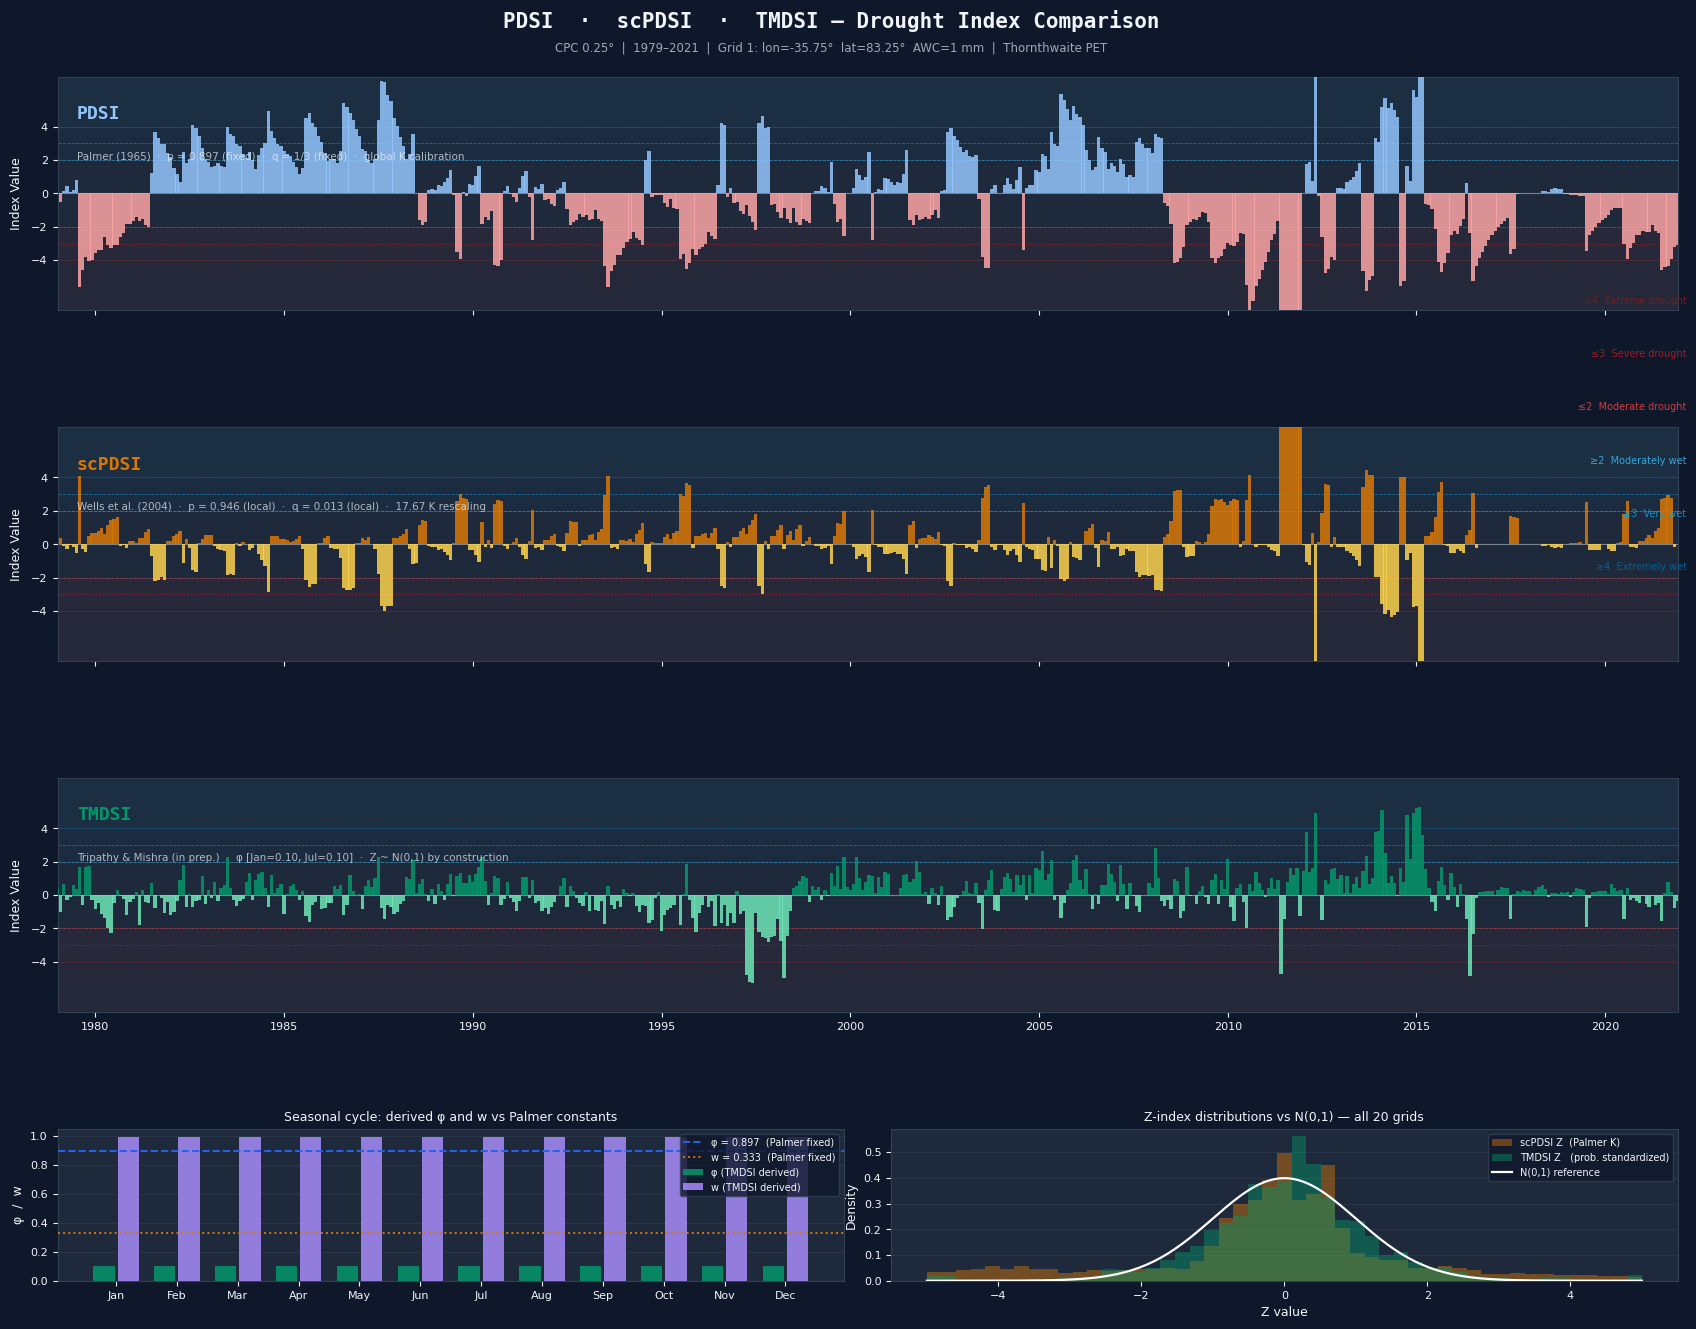


Plot saved: drought_comparison_grid1.png


In [13]:
# %%
# ============================================================
# 4. HIGH-QUALITY COMPARISON PLOT — GRID 0
# ============================================================

g = 14   # first grid cell
dates = pd.date_range("1979-01", periods=N_MONTHS, freq="MS")

# --- colour palette -----------------------------------------------------------
C_PDSI   = "#2563EB"    # deep blue
C_SCPDSI = "#D97706"    # amber
C_TMDSI  = "#059669"    # emerald
C_BG     = "#0F172A"    # near-black
C_PANEL  = "#1E293B"    # dark panel
C_TEXT   = "#F1F5F9"    # off-white
C_GRID   = "#334155"    # subtle grid lines
C_DRY    = "#EF4444"    # drought thresholds
C_WET    = "#38BDF8"    # wet thresholds

# drought classification thresholds
THRESH = [
    (-4.0, "Extreme drought",   "#7F1D1D"),
    (-3.0, "Severe drought",    "#B91C1C"),
    (-2.0, "Moderate drought",  "#EF4444"),
    ( 2.0, "Moderately wet",    "#38BDF8"),
    ( 3.0, "Very wet",          "#0EA5E9"),
    ( 4.0, "Extremely wet",     "#0369A1"),
]

fig = plt.figure(figsize=(18, 14), facecolor=C_BG)
fig.patch.set_facecolor(C_BG)

gs = gridspec.GridSpec(
    4, 2,
    figure=fig,
    hspace=0.55, wspace=0.06,
    left=0.07, right=0.97,
    top=0.93, bottom=0.07,
    height_ratios=[1.0, 1.0, 1.0, 0.65],
)

ax1 = fig.add_subplot(gs[0, :])    # PDSI full width
ax2 = fig.add_subplot(gs[1, :])    # scPDSI
ax3 = fig.add_subplot(gs[2, :])    # TMDSI
ax4 = fig.add_subplot(gs[3, 0])    # phi seasonal cycle
ax5 = fig.add_subplot(gs[3, 1])    # Z distribution

axes_ts = [ax1, ax2, ax3]

# ── helper: styled time-series bar chart ──────────────────────────────────────
def plot_ts(ax, vals, color_pos, color_neg, label, subtitle):
    vals = np.array(vals, dtype=float)
    pos = np.where(vals >= 0, vals, 0.0)
    neg = np.where(vals <  0, vals, 0.0)

    ax.bar(dates, pos, color=color_pos, width=32, linewidth=0, alpha=0.85, zorder=3)
    ax.bar(dates, neg, color=color_neg, width=32, linewidth=0, alpha=0.85, zorder=3)

    # horizontal reference lines
    for th, lbl, col in THRESH:
        ax.axhline(th, color=col, lw=0.6, ls="--", alpha=0.55, zorder=2)

    ax.axhline(0, color=C_TEXT, lw=0.8, alpha=0.4, zorder=2)
    ax.set_facecolor(C_PANEL)
    ax.set_xlim(dates[0], dates[-1])
    ax.set_ylim(-7, 7)
    ax.set_yticks([-4, -2, 0, 2, 4])
    ax.tick_params(colors=C_TEXT, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(C_GRID)
    ax.yaxis.grid(True, color=C_GRID, lw=0.4, zorder=1)
    ax.set_ylabel("Index Value", color=C_TEXT, fontsize=9, labelpad=6)

    # label top-left
    ax.text(0.012, 0.88, label, transform=ax.transAxes,
            fontsize=13, fontweight="bold", color=color_pos, va="top",
            fontfamily="monospace")
    ax.text(0.012, 0.68, subtitle, transform=ax.transAxes,
            fontsize=7.5, color=C_TEXT, va="top", alpha=0.7)

plot_ts(ax1, pdsi_out[:, g],   "#93C5FD", "#FCA5A5",
        "PDSI",
        "Palmer (1965)  ·  p = 0.897 (fixed)  ·  q = 1/3 (fixed)  ·  global K calibration")

plot_ts(ax2, scpdsi_out[:, g], C_SCPDSI,  "#FCD34D",
        "scPDSI",
        f"Wells et al. (2004)  ·  p = {sc_p[g]:.3f} (local)  ·  q = {sc_q[g]:.3f} (local)  ·  17.67 K rescaling")

plot_ts(ax3, tmdsi_out[:, g],  C_TMDSI,   "#6EE7B7",
        "TMDSI",
        f"Tripathy & Mishra (in prep.)  ·  φ [Jan={tm_phi[0,g]:.2f}, Jul={tm_phi[6,g]:.2f}]  ·  Z ~ N(0,1) by construction")

# only bottom axis shows x-ticks
ax1.set_xticklabels([]); ax2.set_xticklabels([])
ax3.tick_params(axis="x", colors=C_TEXT, labelsize=8)

# ── Drought classification shading legend (shared right side) ─────────────────
for ax in axes_ts:
    ax.fill_betweenx([-7, -4], dates[0], dates[-1],
                     color="#7F1D1D", alpha=0.08, zorder=0)
    ax.fill_betweenx([-4, -2], dates[0], dates[-1],
                     color="#B91C1C", alpha=0.06, zorder=0)
    ax.fill_betweenx([ 2,  4], dates[0], dates[-1],
                     color="#0369A1", alpha=0.06, zorder=0)
    ax.fill_betweenx([ 4,  7], dates[0], dates[-1],
                     color="#0369A1", alpha=0.08, zorder=0)

# ── φ seasonal cycle (bottom left) ──────────────────────────────────────────
ax4.set_facecolor(C_PANEL)
x = np.arange(12)
phi_g = tm_phi[:, g]
w_g   = tm_w  [:, g]

bars = ax4.bar(x - 0.2, phi_g, width=0.35, color=C_TMDSI, alpha=0.85,
               label="φ (TMDSI derived)", zorder=3)
ax4.bar(x + 0.2, w_g, width=0.35, color="#A78BFA", alpha=0.85,
        label="w (TMDSI derived)", zorder=3)
ax4.axhline(0.897, color=C_PDSI, lw=1.4, ls="--", zorder=4,
            label="φ = 0.897  (Palmer fixed)")
ax4.axhline(1/3,   color=C_SCPDSI, lw=1.4, ls=":",  zorder=4,
            label="w = 0.333  (Palmer fixed)")

ax4.set_xticks(x)
ax4.set_xticklabels(months, fontsize=7.5, color=C_TEXT)
ax4.set_ylim(0, 1.05)
ax4.tick_params(colors=C_TEXT, labelsize=8)
for sp in ax4.spines.values(): sp.set_edgecolor(C_GRID)
ax4.yaxis.grid(True, color=C_GRID, lw=0.4, zorder=1)
ax4.set_ylabel("φ  /  w", color=C_TEXT, fontsize=9)
ax4.set_title("Seasonal cycle: derived φ and w vs Palmer constants",
              color=C_TEXT, fontsize=9, pad=6)
leg = ax4.legend(fontsize=7, facecolor=C_BG, edgecolor=C_GRID,
                  labelcolor=C_TEXT, loc="upper right")

# ── Z-index distribution (bottom right) ─────────────────────────────────────
ax5.set_facecolor(C_PANEL)
from scipy import stats as scipy_stats

# collect Z across all valid grids
z_sc_all = scpdsi_out[:, :N_RUN].flatten()
z_tm_all = tmdsi_out [:, :N_RUN].flatten()
z_sc_all = z_sc_all[~np.isnan(z_sc_all)]
z_tm_all = z_tm_all[~np.isnan(z_tm_all)]

bins = np.linspace(-5, 5, 50)
ax5.hist(z_sc_all, bins=bins, density=True, color=C_SCPDSI, alpha=0.45,
         label="scPDSI Z  (Palmer K)", zorder=3)
ax5.hist(z_tm_all, bins=bins, density=True, color=C_TMDSI, alpha=0.45,
         label="TMDSI Z   (prob. standardized)", zorder=3)

xr = np.linspace(-5, 5, 200)
ax5.plot(xr, scipy_stats.norm.pdf(xr), color="white", lw=1.6,
         label="N(0,1) reference", zorder=4)

ax5.tick_params(colors=C_TEXT, labelsize=8)
for sp in ax5.spines.values(): sp.set_edgecolor(C_GRID)
ax5.yaxis.grid(True, color=C_GRID, lw=0.4, zorder=1)
ax5.set_xlabel("Z value", color=C_TEXT, fontsize=9)
ax5.set_ylabel("Density", color=C_TEXT, fontsize=9)
ax5.set_title("Z-index distributions vs N(0,1) — all 20 grids",
              color=C_TEXT, fontsize=9, pad=6)
leg2 = ax5.legend(fontsize=7, facecolor=C_BG, edgecolor=C_GRID,
                   labelcolor=C_TEXT)

# ── Main title ────────────────────────────────────────────────────────────────
fig.text(0.5, 0.965,
         "PDSI  ·  scPDSI  ·  TMDSI — Drought Index Comparison",
         ha="center", fontsize=15, fontweight="bold",
         color=C_TEXT, fontfamily="monospace")
fig.text(0.5, 0.948,
         f"CPC 0.25°  |  1979–2021  |  Grid 1: lon={lons[g]:.2f}°  lat={lats[g]:.2f}°  "
         f"AWC={awc_all[g]:.0f} mm  |  Thornthwaite PET",
         ha="center", fontsize=8.5, color=C_TEXT, alpha=0.65)

# drought severity legend (far right text)
for i, (th, lbl, col) in enumerate(THRESH):
    sign = "≤" if th < 0 else "≥"
    fig.text(0.975, 0.77 - i*0.038,
             f"{sign}{abs(th):.0f}  {lbl}",
             ha="right", va="center", fontsize=7,
             color=col, alpha=0.85)

plt.savefig("drought_comparison_grid1.png", dpi=180, bbox_inches="tight",
            facecolor=C_BG)
plt.show()
print("\nPlot saved: drought_comparison_grid1.png")

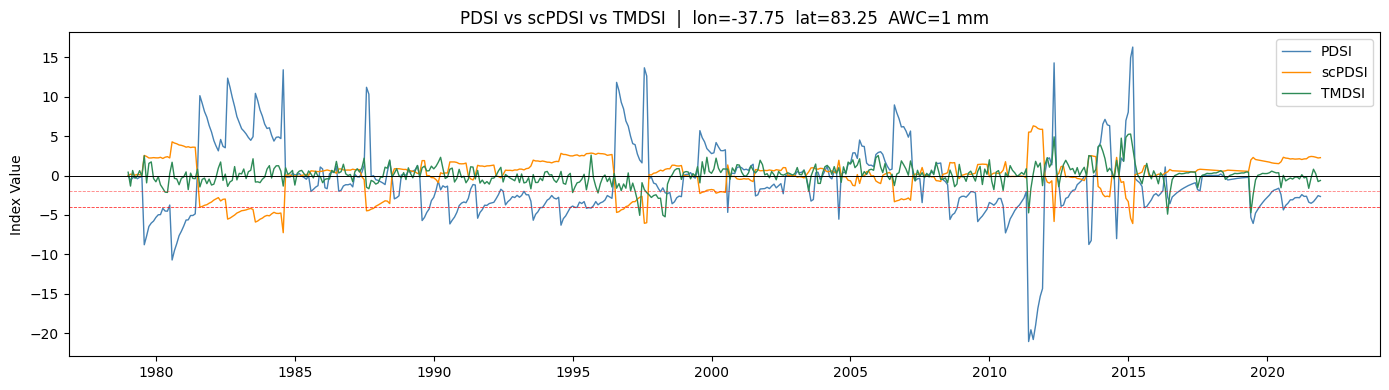

In [31]:
# %%
# %%
# 4. PLOT — Grid 0

g = 10
dates = pd.date_range("1979-01", periods=N_MONTHS, freq="MS")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, pdsi_out[:,   g], color="steelblue",  lw=1.0, label="PDSI")
ax.plot(dates, scpdsi_out[:, g], color="darkorange", lw=1.0, label="scPDSI")
ax.plot(dates, tmdsi_out[:,  g], color="seagreen",   lw=1.0, label="TMDSI")
ax.axhline(0,  color="k",   lw=0.7)
ax.axhline(-2, color="red", lw=0.6, ls="--", alpha=0.5)
ax.axhline(-4, color="red", lw=0.6, ls="--", alpha=0.8)
ax.set_ylabel("Index Value")
ax.set_title(f"PDSI vs scPDSI vs TMDSI  |  lon={lons[g]:.2f}  lat={lats[g]:.2f}  AWC={awc_all[g]:.0f} mm")
ax.legend()
plt.tight_layout()
plt.savefig("drought_comparison_grid.png", dpi=150, bbox_inches="tight")
plt.show()

lon=-99.75  lat=41.75  AWC=612 mm
PDSI   range: -129.08 to 130.67
scPDSI range: -7.30 to 7.61  p=0.933
TMDSI  range: -5.83 to 4.25  Z_std=1.169


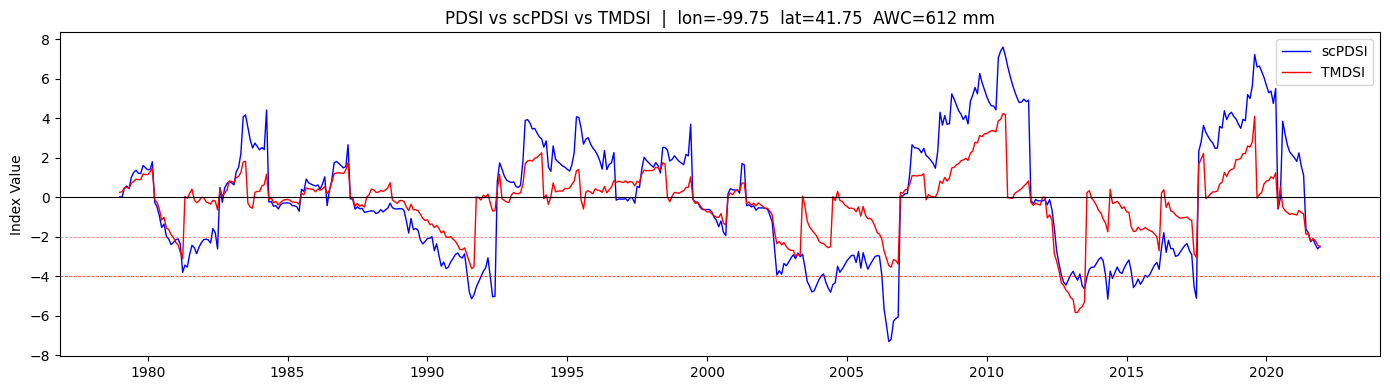

In [17]:
g = 29704
print(f"lon={lons[g]:.2f}  lat={lats[g]:.2f}  AWC={awc_all[g]:.0f} mm")

p  = precip_data[:, g]
tx = tmax_data  [:, g]
tn = tmin_data  [:, g]

kw = dict(
    awc                    = awc_all[g],
    latitude               = lats[g],
    data_start_year        = 1979,
    calibration_start_year = 1979,
    calibration_end_year   = 2010,
    pet_method             = "thornthwaite",
)

r1 = compute_pdsi  (p, tx, tn, **kw)
r2 = compute_scpdsi(p, tx, tn, **kw)
r3 = compute_tmdsi (p, tx, tn, **kw)

print(f"PDSI   range: {np.nanmin(r1.index):.2f} to {np.nanmax(r1.index):.2f}")
print(f"scPDSI range: {np.nanmin(r2.index):.2f} to {np.nanmax(r2.index):.2f}  p={r2.p:.3f}")
print(f"TMDSI  range: {np.nanmin(r3.index):.2f} to {np.nanmax(r3.index):.2f}  Z_std={np.nanstd(r3.z):.3f}")

# plot
dates = pd.date_range("1979-01", periods=N_MONTHS, freq="MS")

fig, ax = plt.subplots(figsize=(14, 4))
# ax.plot(dates, p, color="steelblue",  lw=1.0, label="Precipitation")
# ax.plot(dates, r1.index, color="steelblue",  lw=1.0, label="PDSI")
ax.plot(dates, r2.index, color="blue", lw=1.0, label="scPDSI")
ax.plot(dates, r3.index, color="red",   lw=1.0, label="TMDSI")
ax.axhline(0,  color="k",   lw=0.8)
ax.axhline(-2, color="red", lw=0.6, ls="--", alpha=0.5)
ax.axhline(-4, color="red", lw=0.6, ls="--", alpha=0.8)
ax.set_ylabel("Index Value")
ax.set_title(f"PDSI vs scPDSI vs TMDSI  |  lon={lons[g]:.2f}  lat={lats[g]:.2f}  AWC={awc_all[g]:.0f} mm")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# find months where they disagree in SIGN
disagree = np.where(np.sign(r2.index) != np.sign(r3.index))[0]
print(f"Sign disagreement: {len(disagree)} / {N_MONTHS} months ({100*len(disagree)/N_MONTHS:.1f}%)")

# when they disagree, which one agrees with P-PET?
sc_correct = np.sum(np.sign(r2.index[disagree]) == np.sign(p_minus_pet[disagree]))
tm_correct = np.sum(np.sign(r3.index[disagree]) == np.sign(p_minus_pet[disagree]))
print(f"When disagreeing — scPDSI correct: {sc_correct}, TMDSI correct: {tm_correct}")

Sign disagreement: 68 / 516 months (13.2%)
When disagreeing — scPDSI correct: 24, TMDSI correct: 42


In [20]:
from scipy.stats import binomtest

total_disagree = 68
tmdsi_correct  = 42

# null hypothesis: both equally likely to be correct (p=0.5)
result = binomtest(tmdsi_correct, total_disagree, p=0.5, alternative='greater')
print(f"p-value: {result.pvalue:.4f}")
# if p < 0.05 → TMDSI significantly better at capturing P-PET signal

p-value: 0.0341


In [6]:
from scipy import stats

# compute rolling 3-month P-PET to smooth seasonal noise
p_pet_series = pd.Series(p_minus_pet)
p_pet_3m = p_pet_series.rolling(3, center=True).mean().values

sc  = r2.index
tm  = r3.index

# remove NaN
mask = ~np.isnan(sc) & ~np.isnan(tm) & ~np.isnan(p_pet_3m)

r_sc, p_sc = stats.pearsonr(p_pet_3m[mask], sc[mask])
r_tm, p_tm = stats.pearsonr(p_pet_3m[mask], tm[mask])

# also Spearman (rank-based, more robust)
rs_sc, _ = stats.spearmanr(p_pet_3m[mask], sc[mask])
rs_tm, _ = stats.spearmanr(p_pet_3m[mask], tm[mask])

print(f"              Pearson r    Spearman r")
print(f"scPDSI vs P-PET:  {r_sc:.3f}        {rs_sc:.3f}")
print(f"TMDSI  vs P-PET:  {r_tm:.3f}        {rs_tm:.3f}")

              Pearson r    Spearman r
scPDSI vs P-PET:  0.305        0.323
TMDSI  vs P-PET:  0.327        0.376


In [7]:
import importlib
import tmdsi.indices.drought_indices as di
importlib.reload(di)
from tmdsi.indices.drought_indices import compute_pdsi, compute_scpdsi, compute_tmdsi

# rerun
r1 = compute_pdsi  (p, tx, tn, **kw)
r2 = compute_scpdsi(p, tx, tn, **kw)
r3 = compute_tmdsi (p, tx, tn, **kw)

print(f"q={r2.q:.3f}")   # must now be positive

q=0.241


In [9]:
r_sc, _ = stats.pearsonr(p_pet_3m[mask], r2.index[mask])
r_tm, _ = stats.pearsonr(p_pet_3m[mask], r3.index[mask])
rs_sc, _ = stats.spearmanr(p_pet_3m[mask], r2.index[mask])
rs_tm, _ = stats.spearmanr(p_pet_3m[mask], r3.index[mask])

print(f"              Pearson r    Spearman r")
print(f"scPDSI vs P-PET:  {r_sc:.3f}        {rs_sc:.3f}")
print(f"TMDSI  vs P-PET:  {r_tm:.3f}        {rs_tm:.3f}")

              Pearson r    Spearman r
scPDSI vs P-PET:  0.305        0.323
TMDSI  vs P-PET:  0.327        0.376


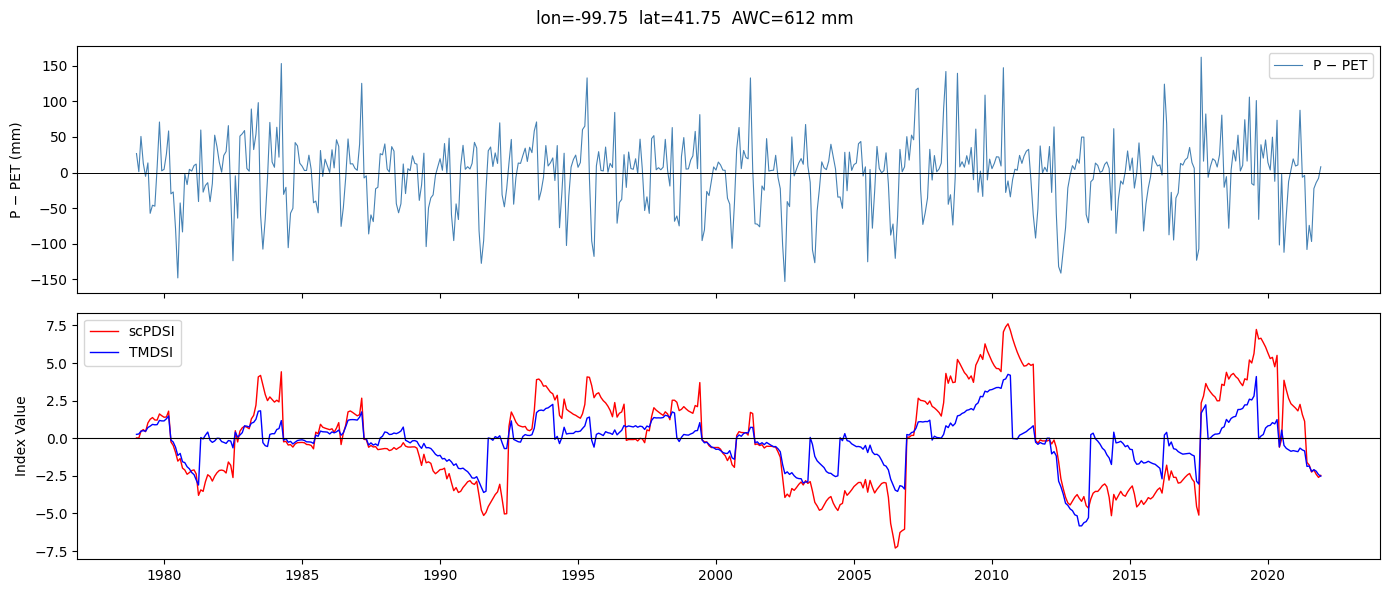

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax1.plot(dates, p_minus_pet, color="steelblue", lw=0.8, label="P − PET")
ax1.axhline(0, color="k", lw=0.7)
ax1.set_ylabel("P − PET (mm)")
ax1.legend()
ax2.plot(dates, r2.index, color="red",  lw=1.0, label="scPDSI")
ax2.plot(dates, r3.index, color="blue", lw=1.0, label="TMDSI")
ax2.axhline(0, color="k", lw=0.8)
ax2.set_ylabel("Index Value")
ax2.legend()
fig.suptitle(f"lon={lons[g]:.2f}  lat={lats[g]:.2f}  AWC={awc_all[g]:.0f} mm")
plt.tight_layout()
plt.show()

In [40]:
print("TMDSI phi:", r3.phi)   # if these are ~0.1, memory is near zero every month
print("TMDSI w  :", r3.w)

TMDSI phi: [0.85914099 0.90608993 0.89175658 0.93299707 0.91734703 0.8796323
 0.85309866 0.90601255 0.95964501 0.98727766 0.96880021 0.88569504]
TMDSI w  : [0.51173896 0.42308515 0.45251543 0.35988397 0.39808847 0.47565431
 0.52174962 0.42325081 0.28121423 0.15900574 0.24784299 0.46426749]


In [34]:
# find a good semi-arid continental grid
# criteria: AWC > 100mm, lat 25-50, valid climate data, not coastal
for g in range(N_GRIDS):
    if (awc_all[g] > 100
        and 25 < lats[g] < 50
        and not np.all(np.isnan(precip_data[:, g]))
        and not np.all(np.isnan(tmax_data[:, g]))):
        print(f"g={g}  lon={lons[g]:.2f}  lat={lats[g]:.2f}  AWC={awc_all[g]:.0f} mm")
        break

g=23482  lon=0.75  lat=49.75  AWC=612 mm


In [41]:
# France should be ~100-180mm
print(awc_all[g])   # what does your array say?

300.0


In [45]:
print(f"scPDSI p={r2.p:.3f}  q={r2.q:.3f}")

scPDSI p=0.946  q=-0.240


In [43]:
# Kansas — where Palmer originally calibrated
for g in range(N_GRIDS):
    if (-100 < lons[g] < -95 and
        37 < lats[g] < 42 and
        awc_all[g] > 80 and
        not np.all(np.isnan(precip_data[:, g]))):
        print(f"g={g}  lon={lons[g]:.2f}  lat={lats[g]:.2f}  AWC={awc_all[g]:.0f}")
        break

g=29704  lon=-99.75  lat=41.75  AWC=300
